# Seleccion del dataset: ML1 Examen Aplicado

Este notebook cubre la seleccion del dataset, el analisis exploratorio inicial (EDA), la division train/test con preprocesamiento sin leakage, PCA, K-Means y el modelado supervisado con validacion cruzada, hasta el punto "8. Modelos supervisados con validacion cruzada" del flujo del examen. El diagnostico del mejor modelo, la justificacion, las conclusiones ejecutivas y el video de presentacion se agregan en una etapa posterior del proyecto.

**Contenido de este notebook:**
1. Preparacion de cuenta y token de Hugging Face (para pasos futuros del proyecto).
2. Declaracion del dataset elegido y carga inicial con pandas.
3. Valores faltantes y tratamiento de outliers.
4. Analisis exploratorio (correlaciones, scatterplots, pairplot).
5. Division train/test y preprocesamiento sin leakage.
6. PCA y contribuciones de variables.
7. K-Means y perfil de clusters.
8. Modelos supervisados con validacion cruzada (Ridge y Random Forest).


## 1. Crear cuenta y token de acceso en Hugging Face

Aunque el dataset elegido para este examen no requiere autenticacion, se deja preparada la cuenta y el token de Hugging Face para etapas futuras del proyecto (por ejemplo, si se necesita descargar un dataset o modelo alojado en el Hub). Pasos:

1. Ir a [huggingface.co/join](https://huggingface.co/join) y crear una cuenta gratuita con correo electronico o con una cuenta existente (Google/GitHub).
2. Verificar el correo electronico desde el enlace de confirmacion enviado por Hugging Face.
3. Iniciar sesion y entrar a [huggingface.co/settings/tokens](https://huggingface.co/settings/tokens).
4. Hacer clic en **New token**, asignarle un nombre (por ejemplo `ml1-examen`) y elegir el rol **Read** (suficiente para leer datasets y modelos publicos).
5. Copiar el token generado (comienza con `hf_...`) y guardarlo en un lugar seguro; Hugging Face no vuelve a mostrarlo completo despues de cerrar la ventana.
6. Crear un archivo `.env` local, en la raiz del proyecto, con la linea `HF_TOKEN=tu_token_copiado`. Este archivo **no se sube a git** (esta excluido en `.gitignore`).
7. Cargar el token en Python con `python-dotenv`, como se muestra en la celda siguiente.

In [1]:
import os
from dotenv import load_dotenv

load_dotenv()
hf_token_available = bool(os.getenv('HF_TOKEN'))
print(f'Token de Hugging Face disponible en el entorno: {hf_token_available}')
print('El dataset de esta seccion se obtiene desde scikit-learn y no requiere el token; queda preparado para pasos futuros.')

Token de Hugging Face disponible en el entorno: False
El dataset de esta seccion se obtiene desde scikit-learn y no requiere el token; queda preparado para pasos futuros.


## 2. Declaracion del dataset elegido

**Nombre:** California Housing  
**Fuente:** scikit-learn / StatLib  
**URL publica:** https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html  
**Numero de filas:** 20.640  
**Numero de columnas:** 9 (8 predictoras + 1 objetivo)  
**Variable objetivo:** `MedHouseValue`, valor mediano de vivienda en cientos de miles de dolares  
**Tipo de tarea:** regresion supervisada  

**Justificacion:** el dataset es publico, verificable y cumple los minimos exigidos (mas de 500 observaciones, minimo 6 variables predictoras con al menos 3 numericas continuas). No corresponde a ninguno de los datasets excluidos por la ficha del examen (Iris, Titanic, Boston, Breast Cancer, Digits, Wine, Diabetes).

In [2]:
from pathlib import Path
import time
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
Path('figures').mkdir(exist_ok=True)
Path('results').mkdir(exist_ok=True)
sns.set_theme(style='whitegrid', context='notebook')

housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()
df = df.rename(columns={'MedHouseVal': 'MedHouseValue'})
target = 'MedHouseValue'
print('df.shape:', df.shape)
print('df.dtypes:')
display(df.dtypes)
print('df.info():')
df.info()
print('df.describe():')
display(df.describe().T)
print('df.head():')
display(df.head())


df.shape: (20640, 9)
df.dtypes:


MedInc           float64
HouseAge         float64
AveRooms         float64
AveBedrms        float64
Population       float64
AveOccup         float64
Latitude         float64
Longitude        float64
MedHouseValue    float64
dtype: object

df.info():
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MedInc         20640 non-null  float64
 1   HouseAge       20640 non-null  float64
 2   AveRooms       20640 non-null  float64
 3   AveBedrms      20640 non-null  float64
 4   Population     20640 non-null  float64
 5   AveOccup       20640 non-null  float64
 6   Latitude       20640 non-null  float64
 7   Longitude      20640 non-null  float64
 8   MedHouseValue  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
df.describe():


,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseValue,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


df.head():


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 3. Valores faltantes y tratamiento de outliers
California Housing no suele presentar nulos. Se verifica explícitamente y se conserva la estrategia de imputación mediana en el pipeline para que el flujo sea robusto si aparece un archivo con faltantes. Los extremos de vivienda son observaciones válidas, por lo que no se eliminan: el siguiente recorte IQR es solo una vista diagnostica para comparar boxplots; el modelado conserva los datos originales y evita leakage.

,missing_percent
MedInc,0.0
HouseAge,0.0
AveRooms,0.0
AveBedrms,0.0
Population,0.0
AveOccup,0.0
Latitude,0.0
Longitude,0.0
MedHouseValue,0.0


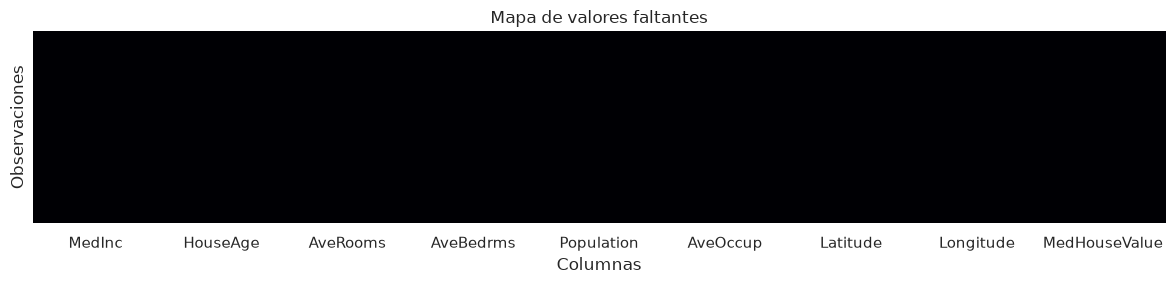

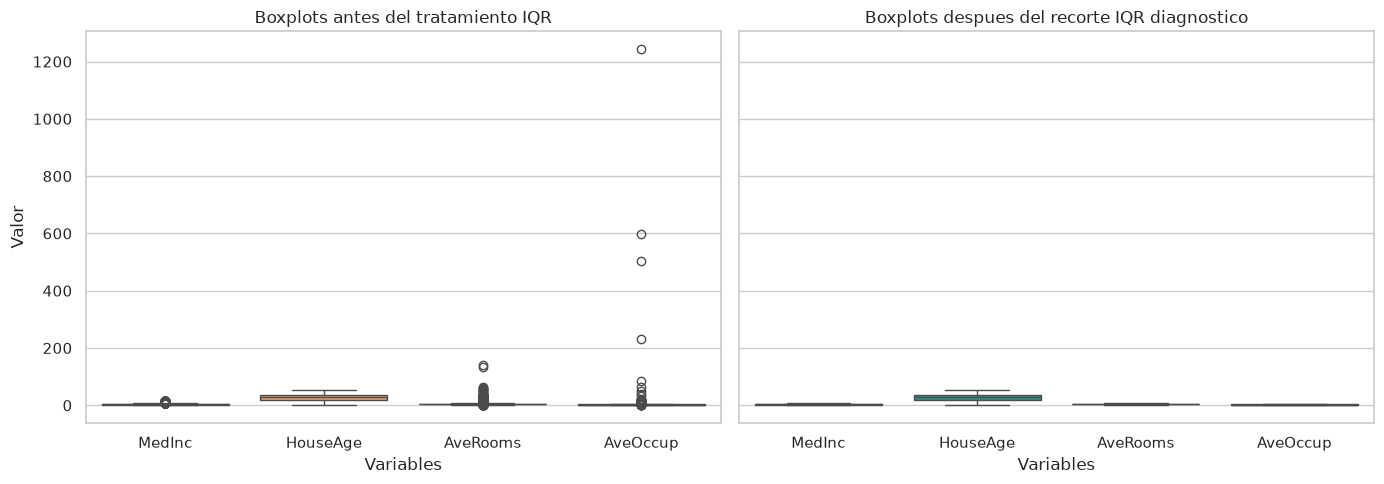

In [3]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
display(missing_pct.to_frame('missing_percent'))
plt.figure(figsize=(12, 3))
sns.heatmap(df.isna(), cbar=False, yticklabels=False, cmap='magma')
plt.title('Mapa de valores faltantes')
plt.xlabel('Columnas')
plt.ylabel('Observaciones')
plt.tight_layout()
plt.savefig('figures/missing_values_heatmap.png', dpi=150)
plt.show()

key_features = ['MedInc', 'HouseAge', 'AveRooms', 'AveOccup']
outlier_bounds = {}
df_iqr = df.copy()
for column in key_features:
    q1, q3 = df[column].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outlier_bounds[column] = (lower, upper)
    df_iqr[column] = df[column].clip(lower, upper)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
sns.boxplot(data=df[key_features], ax=axes[0], color='#f4a261')
axes[0].set_title('Boxplots antes del tratamiento IQR')
axes[0].set_xlabel('Variables')
axes[0].set_ylabel('Valor')
sns.boxplot(data=df_iqr[key_features], ax=axes[1], color='#2a9d8f')
axes[1].set_title('Boxplots despues del recorte IQR diagnostico')
axes[1].set_xlabel('Variables')
plt.tight_layout()
plt.savefig('figures/boxplots_before_after_iqr.png', dpi=150)
plt.show()

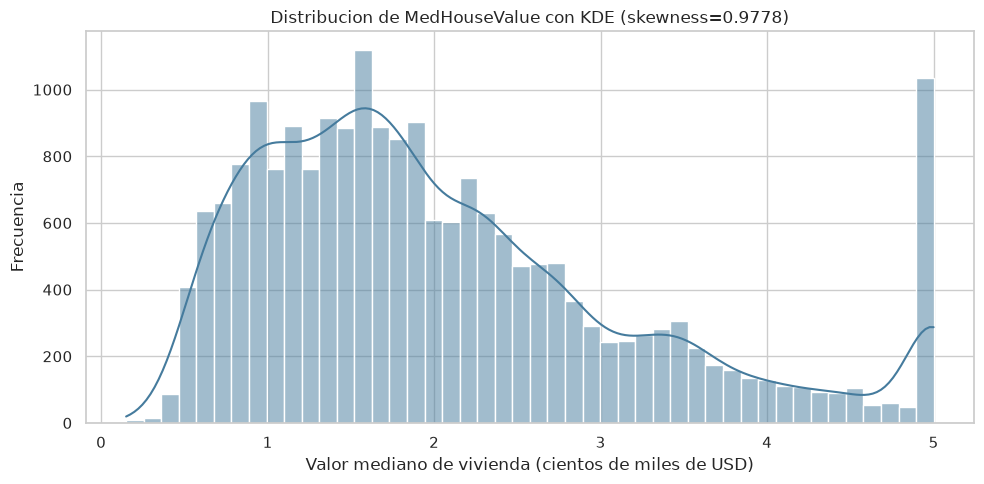

Skewness de MedHouseValue: 0.9778
Decision: no se aplica log1p porque la variable objetivo no requiere una transformacion extrema para este modelo base; se evaluan metricas sobre la escala original.


In [4]:
skewness = df[target].skew()
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df[target], kde=True, ax=ax, color='#457b9d')
ax.set_title(f'Distribucion de {target} con KDE (skewness={skewness:.4f})')
ax.set_xlabel('Valor mediano de vivienda (cientos de miles de USD)')
ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.savefig('figures/target_histogram_kde.png', dpi=150)
plt.show()
print(f'Skewness de {target}: {skewness:.4f}')
print('Decision: no se aplica log1p porque la variable objetivo no requiere una transformacion extrema para este modelo base; se evaluan metricas sobre la escala original.')

## 4. Analisis exploratorio
Se usan correlaciones de Pearson, relaciones bivariadas y un pairplot sobre una muestra para mantener la visualizacion legible. Correlacion no implica causalidad; se utiliza como herramienta de priorizacion exploratoria.

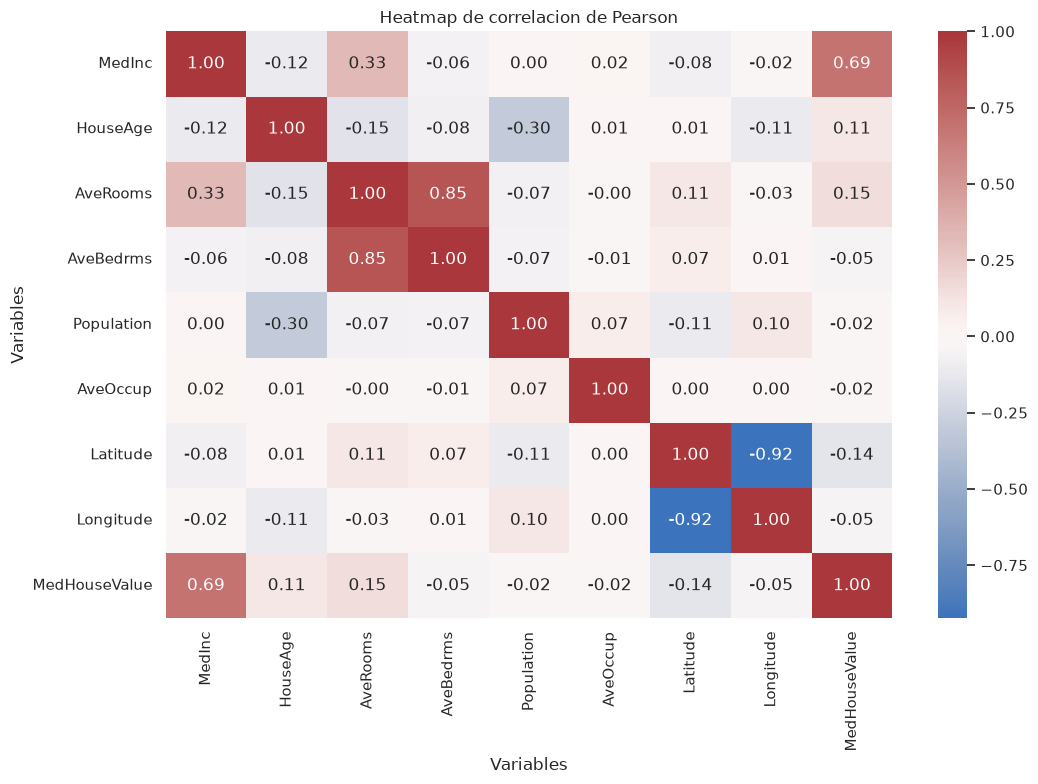

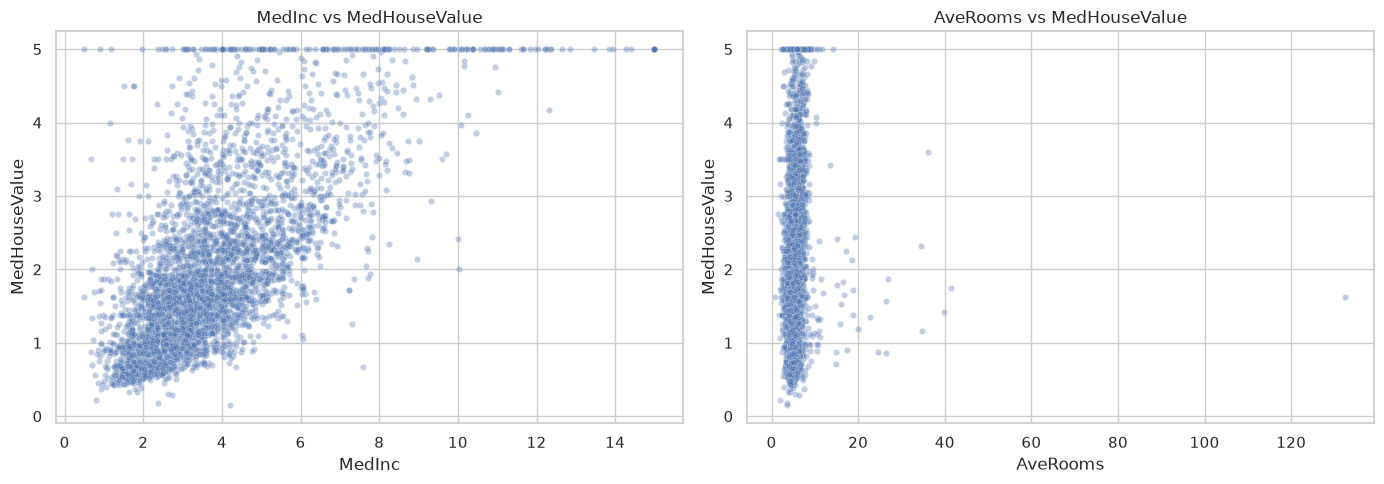

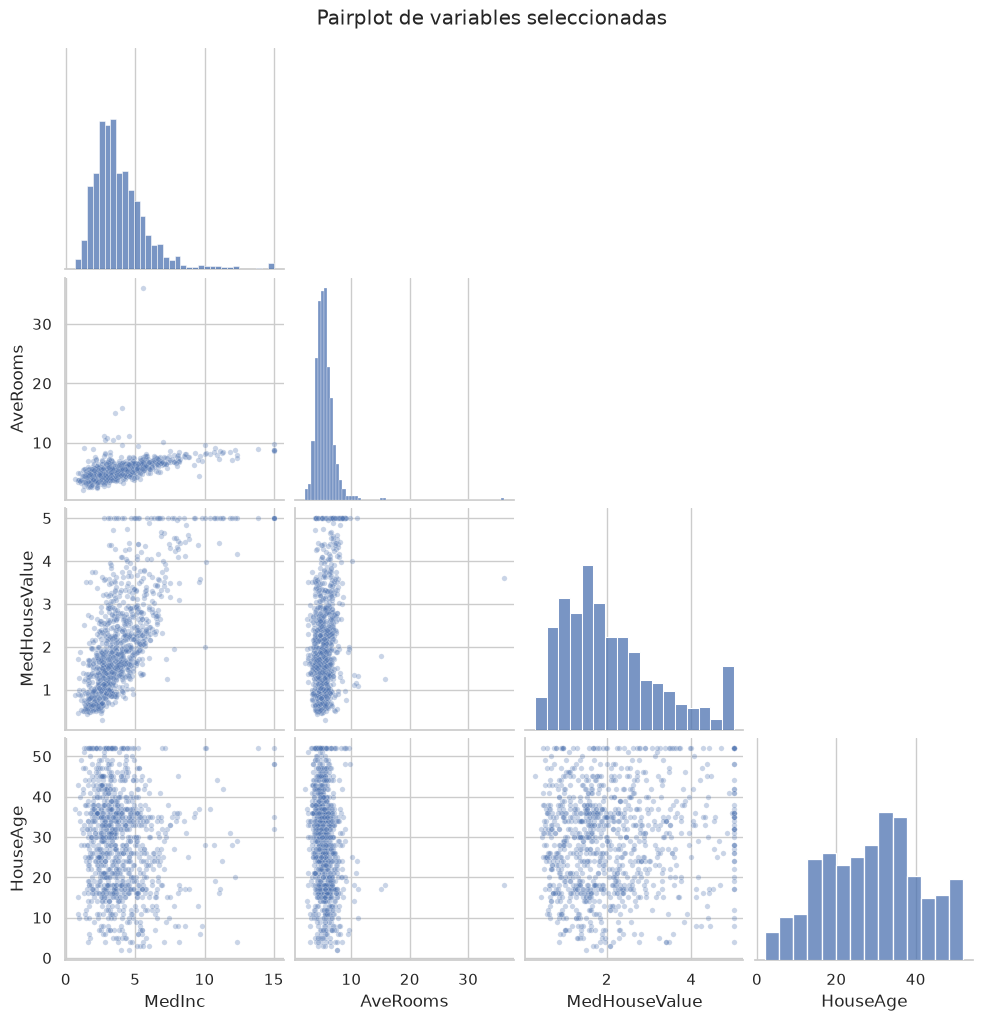

In [5]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(11, 8))
sns.heatmap(corr, cmap='vlag', center=0, annot=True, fmt='.2f')
plt.title('Heatmap de correlacion de Pearson')
plt.xlabel('Variables')
plt.ylabel('Variables')
plt.tight_layout()
plt.savefig('figures/pearson_correlation_heatmap.png', dpi=150)
plt.show()

top_two = corr[target].drop(target).abs().nlargest(2).index.tolist()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, feature in zip(axes, top_two):
    sns.scatterplot(data=df.sample(4000, random_state=RANDOM_STATE), x=feature, y=target, alpha=0.35, s=20, ax=ax)
    ax.set_title(f'{feature} vs {target}')
    ax.set_xlabel(feature)
    ax.set_ylabel(target)
plt.tight_layout()
plt.savefig('figures/top_correlated_scatterplots.png', dpi=150)
plt.show()

pairplot_columns = top_two + [target, 'HouseAge']
pair = sns.pairplot(df[pairplot_columns].sample(1000, random_state=RANDOM_STATE), corner=True, plot_kws={'alpha': 0.3, 's': 15})
pair.fig.suptitle('Pairplot de variables seleccionadas', y=1.02)
pair.fig.savefig('figures/pairplot_selected_features.png', dpi=150)
plt.show()

In [6]:
target_corr = corr[target].drop(target).sort_values(key=np.abs, ascending=False)
print('Cinco variables mas correlacionadas con el objetivo:')
display(target_corr.head(5).to_frame('pearson_r'))

predictor_corr = df.drop(columns=target).corr().abs()
upper_triangle = predictor_corr.where(np.triu(np.ones(predictor_corr.shape), k=1).astype(bool))
high_multicollinearity = (upper_triangle.stack().loc[lambda s: s > 0.85].sort_values(ascending=False))
print('Pares de predictores con |r| > 0.85:')
display(high_multicollinearity.to_frame('absolute_r')) if not high_multicollinearity.empty else print('No se detectaron pares con |r| > 0.85.')

Cinco variables mas correlacionadas con el objetivo:


,pearson_r
MedInc,0.688075
AveRooms,0.151948
Latitude,-0.144160
HouseAge,0.105623
AveBedrms,-0.046701


Pares de predictores con |r| > 0.85:


,,absolute_r
Latitude,Longitude,0.924664


## 5. Division train/test y preprocesamiento sin leakage
La separacion se realiza antes de ajustar imputadores, codificadores, escalador o cualquier modelo. No hay variables categoricas en este dataset; aun asi, el `ColumnTransformer` deja declarados los ramales nominal y ordinal para documentar la arquitectura solicitada.


In [7]:
X = df.drop(columns=target)
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print('X_train:', X_train.shape)
print('X_test:', X_test.shape)

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
nominal_features = []
ordinal_features = []
numeric_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
nominal_pipeline = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
ordinal_pipeline = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))])
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('nominal', nominal_pipeline, nominal_features),
    ('ordinal', ordinal_pipeline, ordinal_features),
], remainder='drop', verbose_feature_names_out=False)
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()
print('Dimensiones preprocesadas:', X_train_prep.shape, X_test_prep.shape)
print('El preprocesador se ajusto solo con X_train.')


X_train: (16512, 8)
X_test: (4128, 8)
Dimensiones preprocesadas: (16512, 8) (4128, 8)
El preprocesador se ajusto solo con X_train.


## 6. PCA y contribuciones de variables
Se elige el primer numero de componentes cuya varianza acumulada queda entre 80% y 90%. Si la discretizacion no ofrece un valor dentro del intervalo, se utiliza el primer componente que supera 80% y se reporta la decision.


,component,explained_variance_ratio,cumulative_variance
0,1,0.253138,0.253138
1,2,0.234032,0.487170
2,3,0.159172,0.646342
3,4,0.129769,0.776111
4,5,0.125472,0.901583
5,6,0.082165,0.983748
6,7,0.010342,0.994090
7,8,0.005910,1.000000


n_components seleccionado: 5
Varianza acumulada seleccionada: 0.9016


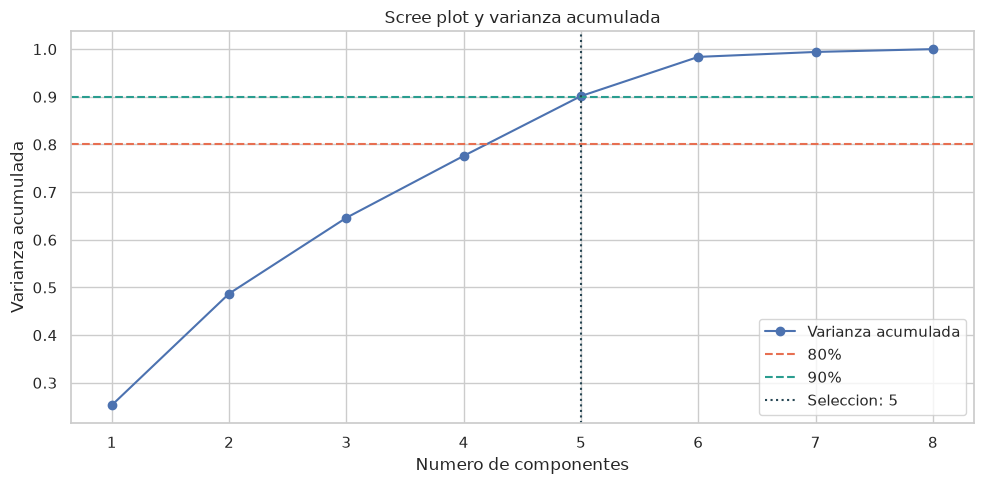

Top 5 loadings absolutos de PC1:


,absolute_loading
Latitude,0.567219
Longitude,0.532892
AveRooms,0.445882
AveBedrms,0.401967
Population,0.162598


Top 5 loadings absolutos de PC2:


,absolute_loading
AveRooms,0.539888
AveBedrms,0.493779
Longitude,0.432119
Latitude,0.381085
HouseAge,0.266273


In [8]:
pca_all = PCA(random_state=RANDOM_STATE)
X_train_pca_all = pca_all.fit_transform(X_train_prep)
explained = pd.DataFrame({
    'component': np.arange(1, len(pca_all.explained_variance_ratio_) + 1),
    'explained_variance_ratio': pca_all.explained_variance_ratio_,
    'cumulative_variance': np.cumsum(pca_all.explained_variance_ratio_),
})
display(explained)
valid_components = explained.loc[explained['cumulative_variance'].between(0.80, 0.90), 'component']
n_components = int(valid_components.iloc[0]) if not valid_components.empty else int(explained.loc[explained['cumulative_variance'] >= 0.80, 'component'].iloc[0])
pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_prep)
print(f'n_components seleccionado: {n_components}')
print(f'Varianza acumulada seleccionada: {pca.explained_variance_ratio_.sum():.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(explained['component'], explained['cumulative_variance'], marker='o', label='Varianza acumulada')
ax.axhline(0.80, color='#e76f51', linestyle='--', label='80%')
ax.axhline(0.90, color='#2a9d8f', linestyle='--', label='90%')
ax.axvline(n_components, color='#264653', linestyle=':', label=f'Seleccion: {n_components}')
ax.set_title('Scree plot y varianza acumulada')
ax.set_xlabel('Numero de componentes')
ax.set_ylabel('Varianza acumulada')
ax.legend()
plt.tight_layout()
plt.savefig('figures/pca_scree_plot.png', dpi=150)
plt.show()

loadings = pd.DataFrame(pca.components_.T, index=feature_names, columns=[f'PC{i + 1}' for i in range(n_components)])
for pc in ['PC1', 'PC2']:
    print(f'Top 5 loadings absolutos de {pc}:')
    display(loadings[pc].abs().sort_values(ascending=False).head(5).to_frame('absolute_loading'))


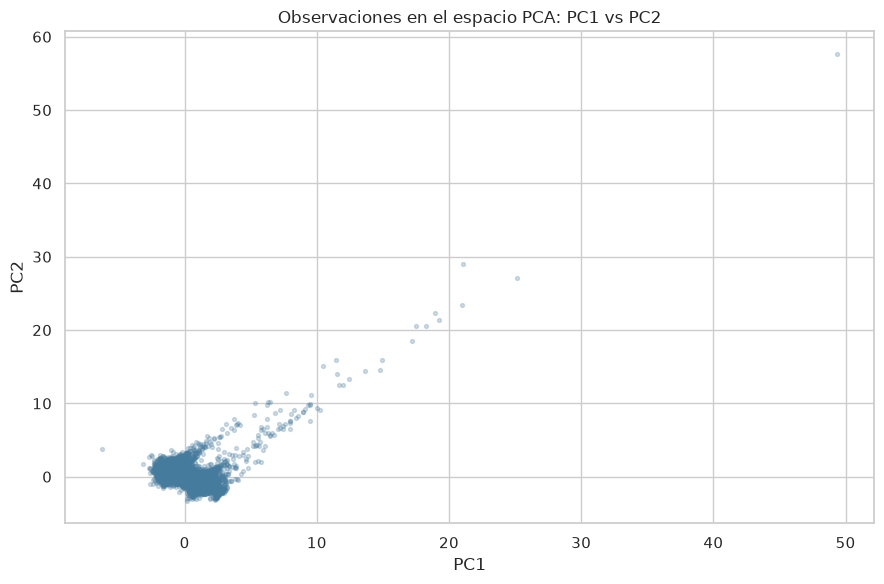

In [9]:
if n_components >= 2:
    plt.figure(figsize=(9, 6))
    plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], s=8, alpha=0.25, color='#457b9d')
    plt.title('Observaciones en el espacio PCA: PC1 vs PC2')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.tight_layout()
    plt.savefig('figures/pca_pc1_pc2.png', dpi=150)
    plt.show()


## 7. K-Means y perfil de clusters
K-Means se ajusta sobre el espacio PCA seleccionado. Se comparan K=2,...,10 con inercia y silhouette; el criterio final prioriza un silhouette alto y una mejora razonable del codo.


,k,inertia,silhouette
0,2,90719.275499,0.374606
1,3,74133.379571,0.380428
2,4,62822.741197,0.380745
3,5,52153.300723,0.339511
4,6,45974.203323,0.344974
5,7,41239.829029,0.302245
6,8,38280.948426,0.303903
7,9,33821.906946,0.304008
8,10,30985.467879,0.302327


K optimo seleccionado por silhouette: 4


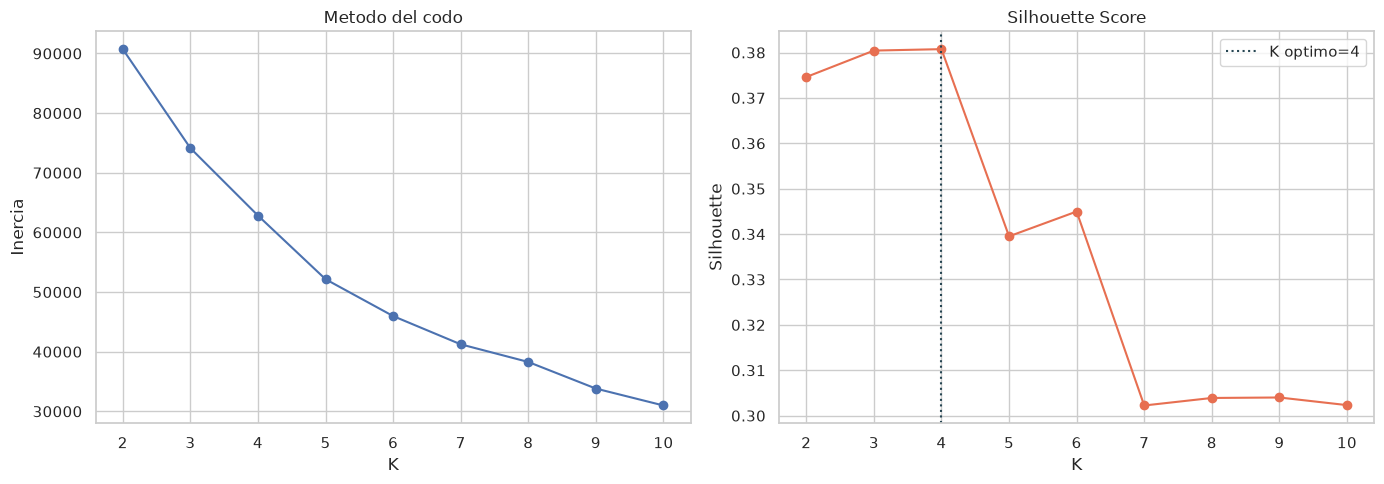

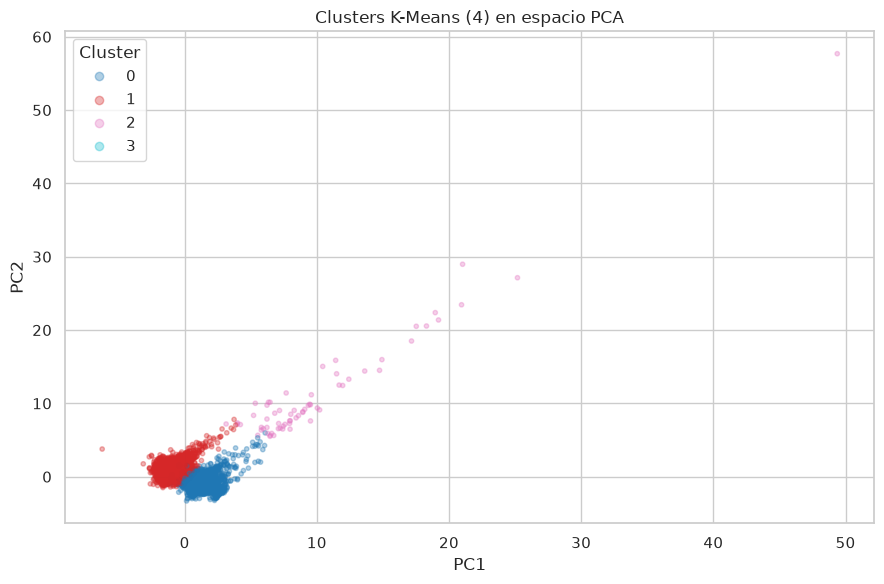

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
cluster,,,,,,,,
0,3.825781,28.896751,5.513614,1.081459,1297.532996,2.923748,37.954361,-121.738435
1,3.923786,28.467283,5.207188,1.072087,1527.165529,3.096571,33.948504,-118.015500
2,3.336702,18.276923,30.523407,6.325833,316.507692,2.527435,37.595385,-119.331692
3,10.226400,45.000000,3.166667,0.833333,7460.000000,1243.333333,38.320000,-121.980000


In [10]:
k_rows = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(X_train_pca)
    k_rows.append({'k': k, 'inertia': kmeans.inertia_, 'silhouette': silhouette_score(X_train_pca, labels)})
k_results = pd.DataFrame(k_rows)
display(k_results)
k_opt = int(k_results.loc[k_results['silhouette'].idxmax(), 'k'])
print(f'K optimo seleccionado por silhouette: {k_opt}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(k_results['k'], k_results['inertia'], marker='o')
axes[0].set_title('Metodo del codo')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inercia')
axes[1].plot(k_results['k'], k_results['silhouette'], marker='o', color='#e76f51')
axes[1].axvline(k_opt, linestyle=':', color='#264653', label=f'K optimo={k_opt}')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette')
axes[1].legend()
plt.tight_layout()
plt.savefig('figures/kmeans_elbow_silhouette.png', dpi=150)
plt.show()

kmeans_final = KMeans(n_clusters=k_opt, random_state=RANDOM_STATE, n_init=10)
train_clusters = kmeans_final.fit_predict(X_train_pca)
fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=train_clusters, cmap='tab10', s=10, alpha=0.35)
ax.set_title(f'Clusters K-Means ({k_opt}) en espacio PCA')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend(*scatter.legend_elements(), title='Cluster')
plt.tight_layout()
plt.savefig('figures/kmeans_clusters_pca.png', dpi=150)
plt.show()

cluster_profile = X_train.copy()
cluster_profile['cluster'] = train_clusters
cluster_means = cluster_profile.groupby('cluster').mean(numeric_only=True)
display(cluster_means)


**Interpretacion de clusters:** los perfiles deben leerse comparando las medias de ingresos (`MedInc`), edad de vivienda (`HouseAge`), habitaciones y ocupacion entre grupos. Un cluster con mayor ingreso y valor objetivo representa zonas con mayor capacidad economica; uno con alta ocupacion puede representar hogares mas densos. K-Means describe segmentos, pero no demuestra causalidad ni reemplaza la validacion del modelo supervisado.


## 8. Modelos supervisados con validacion cruzada
Se entrenan Ridge como modelo penalizado y Random Forest como modelo basado en arboles. Ambos reciben exactamente las variables preprocesadas con estadisticos aprendidos en train. GridSearchCV usa cinco folds y el conjunto test permanece reservado hasta la evaluacion final.


In [11]:
ridge_search = GridSearchCV(
    Ridge(),
    param_grid={'alpha': [0.001, 0.01, 0.1, 1, 10, 100]},
    cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1
)
rf_search = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid={
        'n_estimators': [100, 200],
        'max_depth': [None, 20],
        'min_samples_split': [2, 5],
    },
    cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1
)

searches = {'Ridge': ridge_search, 'Random Forest': rf_search}
fitted_models = {}
training_times = {}
for name, search in searches.items():
    start = time.time()
    search.fit(X_train_prep, y_train)
    training_times[name] = time.time() - start
    fitted_models[name] = search.best_estimator_
    print(f'{name}: best_params_={search.best_params_}')
    print(f'{name}: mejor RMSE CV={-search.best_score_:.4f}; tiempo={training_times[name]:.2f}s')


Ridge: best_params_={'alpha': 0.001}
Ridge: mejor RMSE CV=0.7205; tiempo=3.30s


Random Forest: best_params_={'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
Random Forest: mejor RMSE CV=0.5102; tiempo=102.82s


In [12]:
def regression_metrics(y_true, y_pred):
    return {
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred),
        'MAPE': np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-8))) * 100,
    }

evaluation_rows = []
predictions = {}
for name, model in fitted_models.items():
    y_train_pred = model.predict(X_train_prep)
    y_test_pred = model.predict(X_test_prep)
    predictions[name] = y_test_pred
    train_metrics = regression_metrics(y_train, y_train_pred)
    test_metrics = regression_metrics(y_test, y_test_pred)
    evaluation_rows.append({
        'model': name,
        'RMSE': test_metrics['RMSE'],
        'MAE': test_metrics['MAE'],
        'R2': test_metrics['R2'],
        'MAPE_percent': test_metrics['MAPE'],
        'train_RMSE': train_metrics['RMSE'],
        'train_R2': train_metrics['R2'],
        'training_time_seconds': training_times[name],
    })
results = pd.DataFrame(evaluation_rows).sort_values('RMSE').reset_index(drop=True)
display(results.style.format({column: '{:.4f}' for column in results.columns if column != 'model'}))
results.to_csv('results/model_comparison.csv', index=False)
print('Tabla exportada a results/model_comparison.csv')


,model,RMSE,MAE,R2,MAPE_percent,train_RMSE,train_R2,training_time_seconds
0,Random Forest,0.5045,0.3271,0.8058,18.8549,0.1906,0.9728,102.8226
1,Ridge,0.7456,0.5332,0.5758,31.9522,0.7197,0.6126,3.2978


Tabla exportada a results/model_comparison.csv


## Proximos pasos

El diagnostico del mejor modelo (residuales, importancia de variables, observaciones con mayor error), la justificacion del modelo seleccionado, las conclusiones ejecutivas y el video de presentacion se desarrollaran en una etapa posterior del proyecto, siguiendo la bitacora documentada en el `README.md` de este repositorio.
